|<img src="images/usherb_transp.gif" > |Pierre Proulx, ing, professeur|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

In [13]:
#
# Pierre Proulx
#
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp          
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

### Section 2.4, écoulement d'un film de fluide Newtonien dans une conduite annulaire

>Le développement fait dans Transport Phenomena sera répété ici en développant les solutions avec le calculateur formel sympy et en traçant la solution avec sympy.plot.
>Vous pouvez suivre le développement détaillé à l'aide du livre et voir comment les équations de bilans initiales deviennent les profils de vitesse, de force, débit, etc...<img src='images/Chap-2-Section-2-4.png' width="600" height="600">

In [14]:
# Paramètres, variables et fonctions, presque identique à la section 2.3
#
r,delta_r,L,mu,R,P_0,P_L,kappa,rho,g=sp.symbols('r,delta_r,L,mu,R,P_0,P_L,kappa,rho,g')    
C1=sp.symbols('C1')                                                         
phi_rz=sp.Function('phi_rz')
phi_zz=sp.Function('phi_zz')

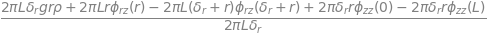

In [15]:
#
# équation identique à la section 2.3
#
#
# Équation du bilan des forces
#
eq=2*sp.pi*r*L*phi_rz(r)      -2*sp.pi*(r+delta_r)*L*phi_rz(r+delta_r)
eq=eq+2*sp.pi*delta_r*r*phi_zz(0)-2*sp.pi*r*delta_r*phi_zz(L)
eq=eq+2*sp.pi*r*delta_r*L*rho*g
#eq=r*phi_rz(r)/delta_r-(r+delta_r)*phi_rz(r+delta_r)/delta_r+r*P_0/L-r*P_L/L 
#
# pose de la limite quand dr tends vers 0
#
eq=eq/(2*sp.pi*L*delta_r)
display(eq)

In [16]:
eq1=sp.limit(eq,delta_r,0).doit()
display(eq1)

In [17]:
eq1=eq1.subs(phi_zz(0),P_0)     # les termes de convection s'annulent comme en 2.2
eq1=eq1.subs(phi_zz(L),P_L)     # mais il reste le terme de pression
display(eq1)

In [18]:
eq1=sp.limit(eq1,delta_r,0).doit()
display(eq1)

In [19]:
#
# encore identique à 2.3
#
tau_rz=sp.Function('tau_rz')
eq2=sp.Eq(eq1.subs(phi_rz(r),tau_rz(r)),0)
display(eq2)

In [20]:
eq2=sp.dsolve(eq2)
v_z=sp.Function('v_z')(r)
newton=-mu*sp.Derivative(v_z,r)
eq3=eq2.subs(tau_rz(r),newton)
display(eq3)

Maintenant la différence avec la section 2.3 arrive, la condition limite pour $C_1$ n'est pas la même car r=0 n'est pas partie du domaine.

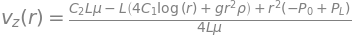

In [21]:
eq4=sp.dsolve(eq3,v_z)
display(eq4)

Maintenant on peut trouver les deux constantes inconnues en solutionnant les deux équations à deux inconnues provenant de la pose des conditions aux limites:


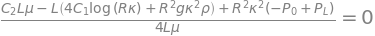

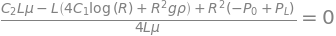

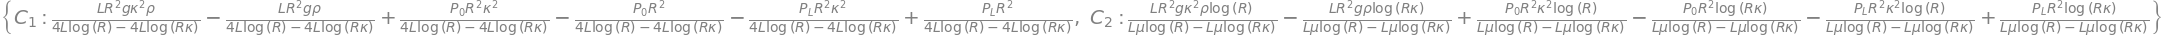

In [22]:
condition_1=sp.Eq(eq4.rhs.subs(r,kappa*R),0)
condition_2=sp.Eq(eq4.rhs.subs(r,R      ),0)
display(condition_1,condition_2)
constante=sp.solve([condition_1,condition_2], sp.symbols('C1,C2'))
display(constante)

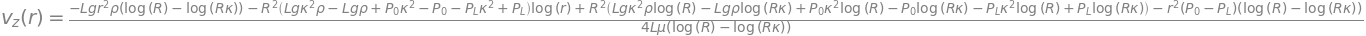

In [23]:
v_z=eq4.subs(constante)
display(v_z.simplify())

In [24]:
from ipywidgets import *
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=8,6
def f(k):
    dico={'rho':1000, 'mu':0.001,'g':-9.81,
              'R':0.05, 'L':10,'P_0':100000,'P_L':0}
    vg=v_z.rhs
    lamb=sp.solve(sp.Eq(vg.diff(r),0),r)[0] # racine, c'est la position de Lambda (Bird)
    lamb=lamb.subs(dico).subs(kappa,k)
    lamb=lamb.evalf()
    vg=vg.subs(dico).subs(kappa,k).evalf()
    ymax=float(vg.subs(r,lamb).evalf(3))*1.10  # limites du graphe
    Rmin=k*R.subs(dico)
    Rmax=R.subs(dico)
#    p=sp.plot(vg,(r,Rmin,Rmax),ylim=[0,ymax],legend=True,show=False)
    p=sp.plot((vg,(r,Rmin,lamb)),(vg,(r,lamb,Rmax)),ylim=[0,ymax],legend=False,show=False)
    string='lambda='+str(lamb)[0:6]+', kappa='+str(k)
    p[0].label=string
    p[0].line_color='red'
    p[1].line_color='black'    
    str2='La position du maximum lambda='+str(lamb)[0:6]+' pour kappa='+str(k)
    p.title=str2
    
    p.show();
trace=interactive(f,k=(0.01,0.99,0.01));
display(trace)

interactive(children=(FloatSlider(value=0.5, description='k', max=0.99, min=0.01, step=0.01), Output()), _dom_…

#### * 1 Exemple de calcul: trouvez la position du maximum de vitesse, c'est le $ \lambda R$ de la figure 2.4-1 

#### La solution est donc l'endroit ou la dérivée de v est nulle, donc on cherche $\lambda R $ tel que $ \frac {dv_z} {dr} |_{r = \lambda R} = 0$

#### * 2 Calculez la pression $P_0$ requise pour pour que l'écoulement soit nul en gardant une hauteur de 10 mètres. Vérifiez ensuite graphiquement que l'écoulement est bien nul en tracant le graphe de la vitesse.